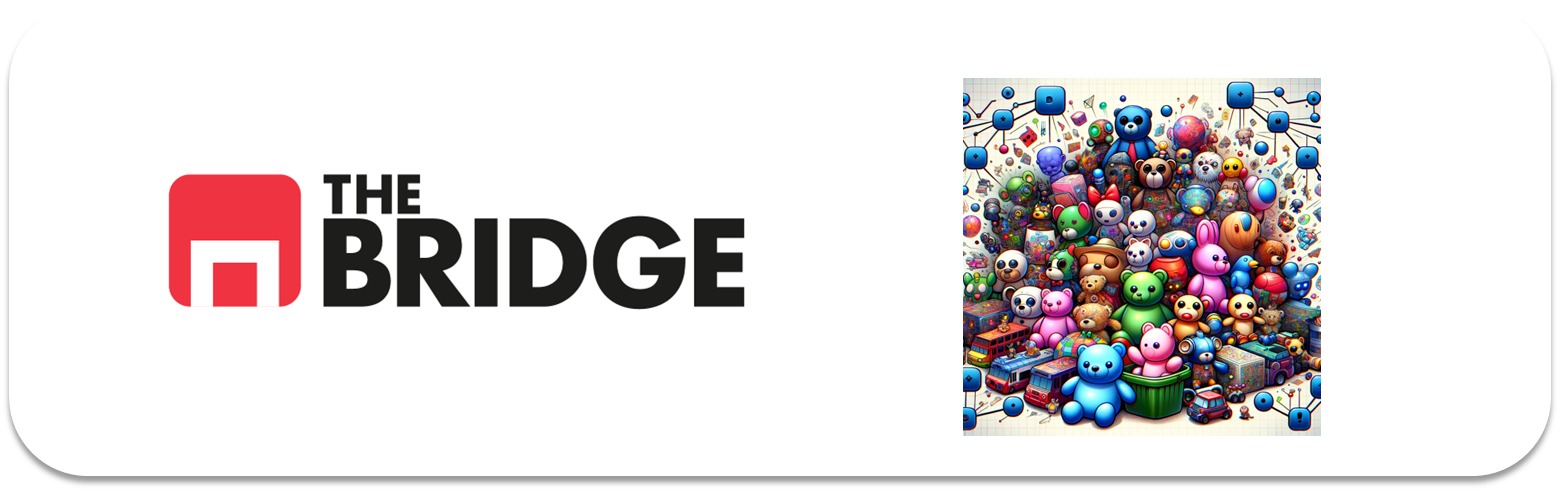

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# ===== Ejercicio 0: imports y configuracion =====
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Algoritmos de clustering y utilidades de sklearn
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics import silhouette_score, adjusted_rand_score

# scipy para el dendrograma del clustering jerarquico
import scipy.cluster.hierarchy as shc

# Modulo de visualizacion del bootcamp (esta en la misma carpeta que el notebook)
import bootcampviztools as bvt

np.random.seed(42)          # reproducibilidad
sns.set_style("whitegrid")

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


#### 1 y 2. Cargar datos y primer vistazo

In [2]:
df = pd.read_csv("./data/empowering_drinks.csv", sep="|")
df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [3]:
print("Dimensiones:", df.shape)
print("Nulos totales:", df.isna().sum().sum())
df.info()

Dimensiones: (153, 5)
Nulos totales: 0
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [4]:
df.describe().round(2)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.00,153.00,153.00,153.00,153.00
mean,0.02,0.04,0.04,0.08,-0.04
std,1.03,1.00,1.04,1.01,0.93
min,-2.43,-3.68,-1.70,-1.49,-1.63
25%,-0.82,-0.50,-1.04,-0.74,-0.80
50%,0.06,-0.02,0.21,-0.17,-0.15
75%,0.88,0.71,0.89,0.92,0.49
max,2.26,3.16,3.06,2.97,2.43


**Observaciones del primer vistazo:**

- Todas numericas: Azucares, Vitaminas del grupo B, Cafeina, Acido Citrico y Taurina.
- **No hay valores nulos** y **no hay variable objetivo**
- En el `describe` vemos que todas las columnas tienen **media ~ 0 y desviacion ~ 1**: los datos **ya vienen estandarizados** (z-scores).

#### 3. MiniEDA: distribuciones y seleccion de features

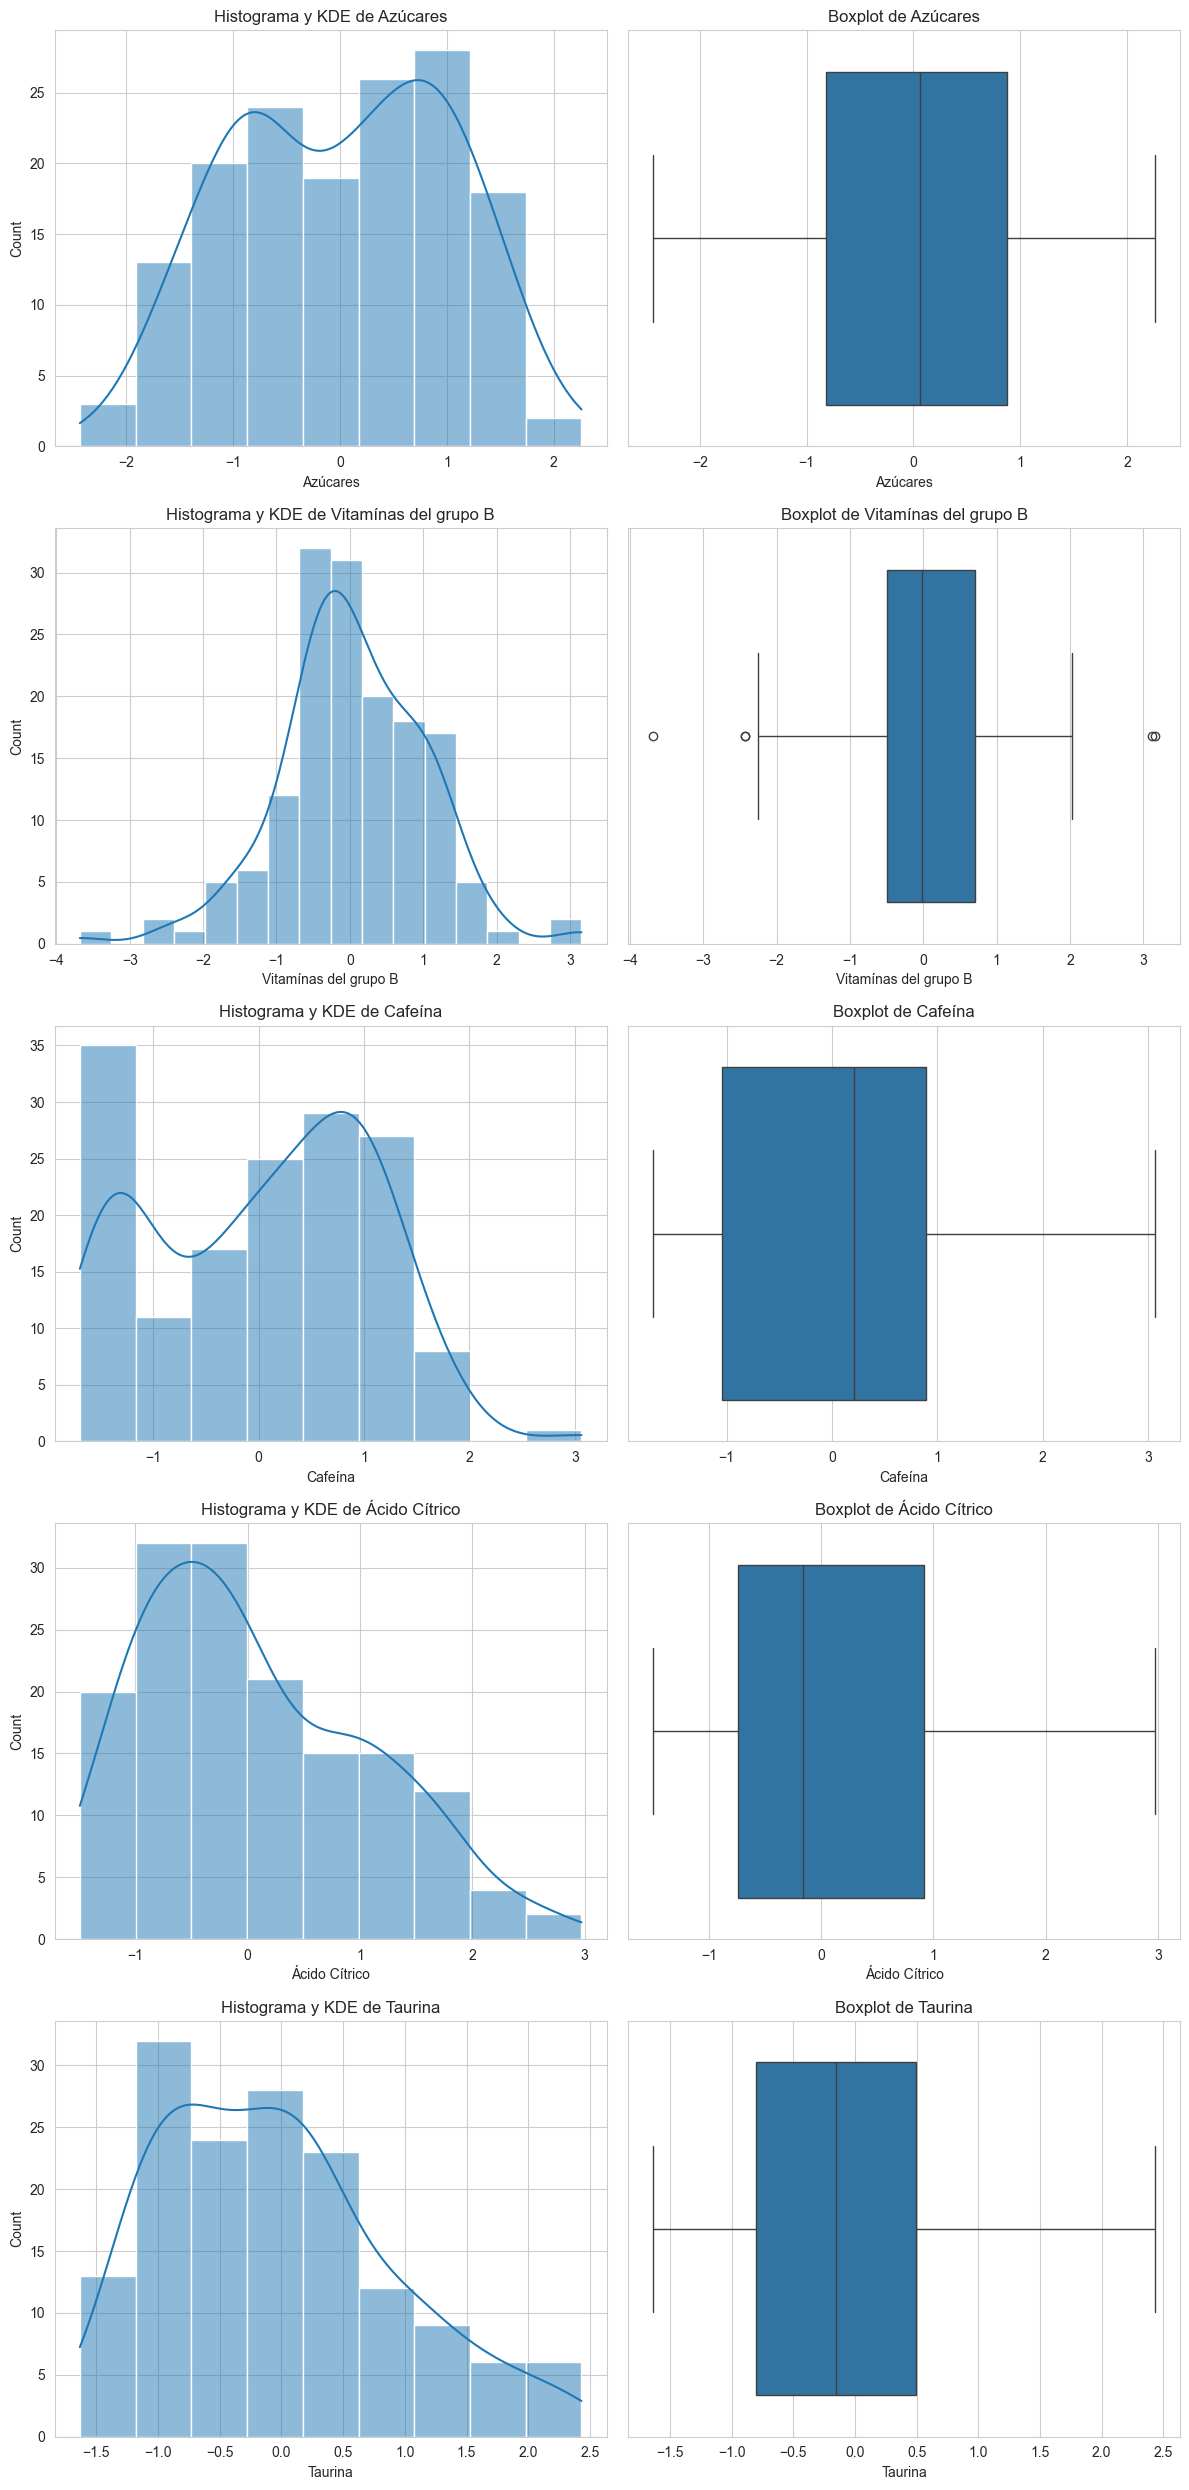

In [5]:
# Histograma + boxplot de cada componente (funcion de bootcampviztools)
bvt.plot_combined_graphs(df, columns=list(df.columns))

Las distribuciones son razonablemente simetricas y centradas en 0. No hay colas extremas que obliguen a transformar (log, raiz...).

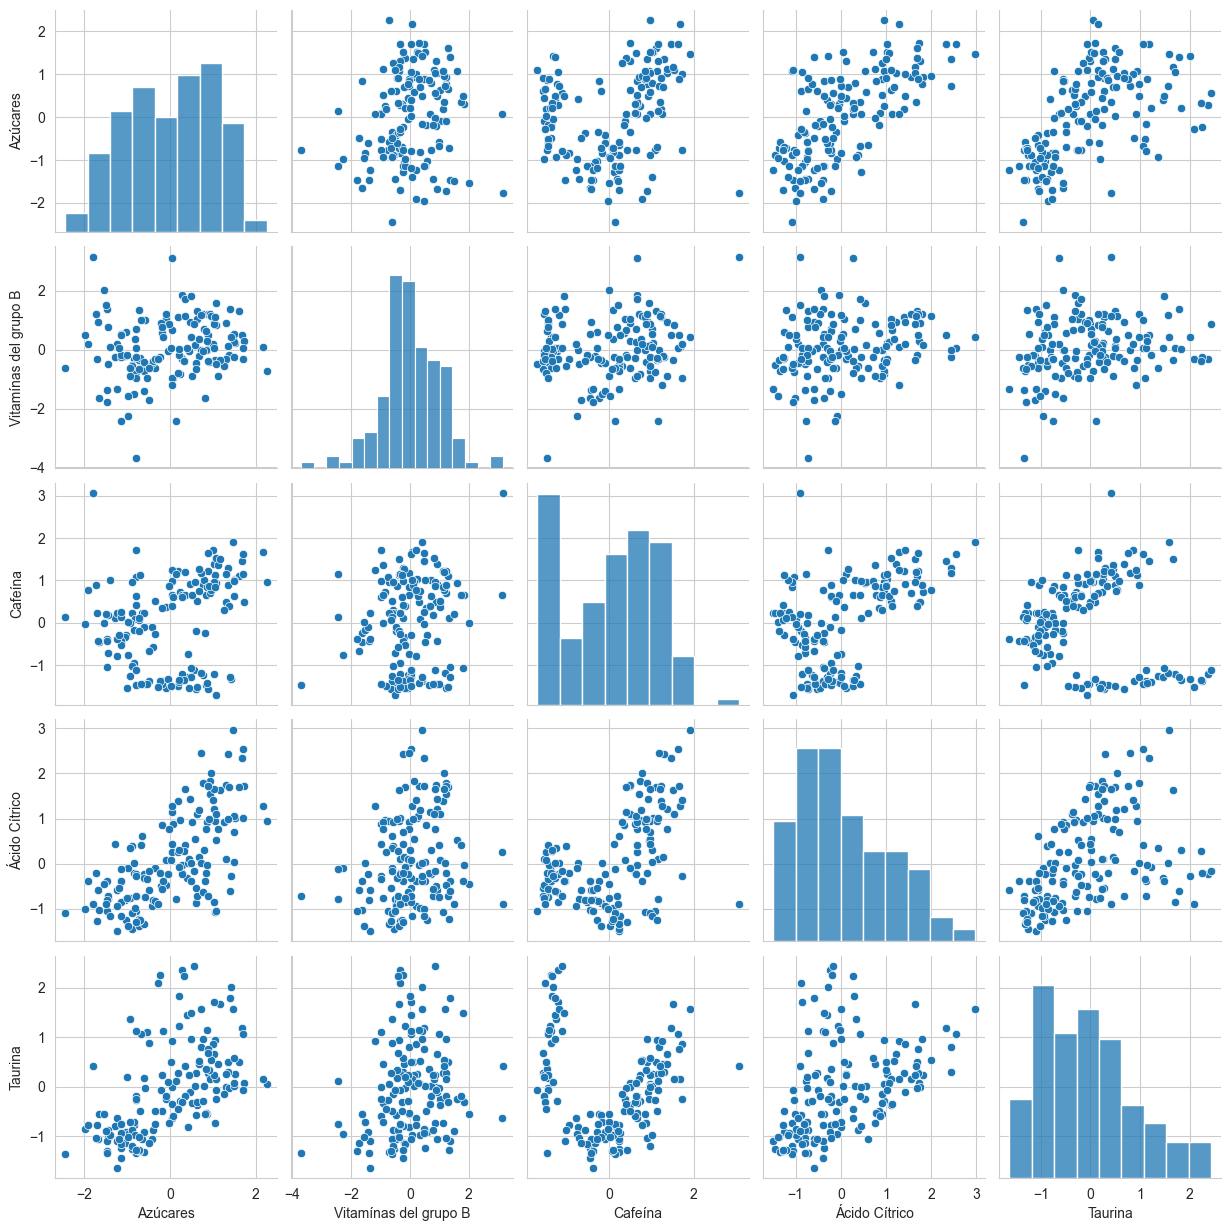

In [6]:
# Visualizamos las features dos a dos para intuir agrupaciones
sns.pairplot(df)
plt.show()

En varias proyecciones se intuye mas de un "grupo" de puntos. Miramos azucar-cafeina y cafeina-taurina en mas detalle:

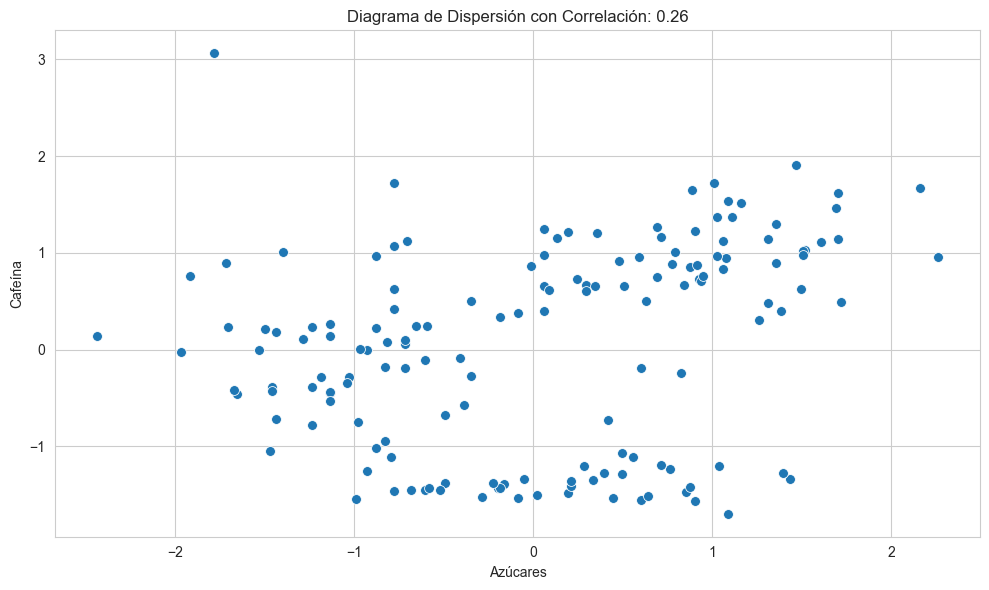

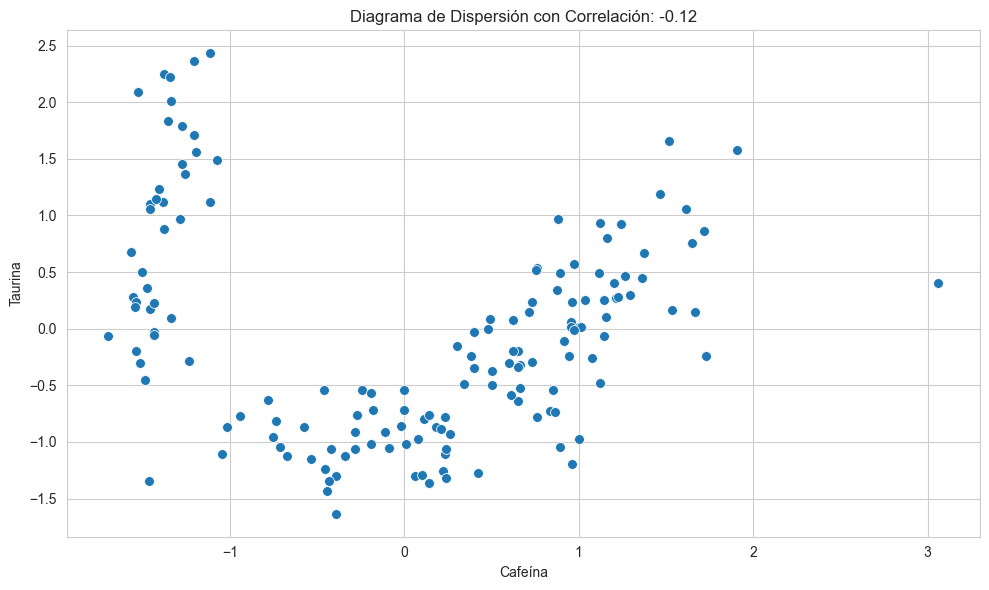

In [7]:
# Guardamos los nombres de las columnas de referencia
COL_X, COL_Y = df.columns[0], df.columns[2]   # Azucares, Cafeina
bvt.grafico_dispersion_con_correlacion(df, COL_X, COL_Y, mostrar_correlacion=True)

COL_X2, COL_Y2 = df.columns[2], df.columns[4]   # Cafeina, Taurina
bvt.grafico_dispersion_con_correlacion(df, COL_X2, COL_Y2, mostrar_correlacion=True)

De todas formas, nos quedamos con las 5 features para no perder informacion en el calculo de distancias.

Los quimicos esperan entre 3 y 5 segmentos. Esto guia la eleccion de hiperparametros.

#### 4 y 5. Modelo A - DBSCAN

DBSCAN agrupa por **densidad**; no fijamos el nº de clusters, sino dos hiperparámetros:
- `eps`: radio del vecindario de cada punto.
- `min_samples`: nº mínimo de vecinos para ser *core*.

Barremos `eps` × `min_samples` buscando **3-5 clusters** con ruido contenido.

In [8]:
# Tabla comparativa DBSCAN: barrido de eps x min_samples
X = df.values
eps_range = np.round(np.arange(0.8, 1.7, 0.1), 2)   # zona util segun el barrido de eps
ms_range  = [4, 6, 8, 10, 12, 15]                   # alrededor de la heuristica 2*features = 10

filas = []
for ms in ms_range:
    for eps in eps_range:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
        n_noise = (lab == -1).sum()
        # la silueta solo tiene sentido con >=2 clusters y se calcula sin el ruido
        mask = lab != -1
        if n_clusters >= 2 and mask.sum() > n_clusters:
            sil = round(silhouette_score(X[mask], lab[mask]), 3)
        else:
            sil = np.nan
        filas.append({"eps": eps, "min_samples": ms, "n_clusters": n_clusters,
                      "pct_ruido": round(100 * n_noise / len(lab), 1), "silueta": sil})

tabla = pd.DataFrame(filas)

# Vista en matriz (eps en filas, min_samples en columnas)
print("Numero de clusters:")
display(tabla.pivot(index="eps", columns="min_samples", values="n_clusters"))

print("% de ruido:")
display(tabla.pivot(index="eps", columns="min_samples", values="pct_ruido"))

# Combinaciones que cumplen la nota de los quimicos (3-5 segmentos), de menos a mas ruido
print("Combinaciones con 3-5 segmentos:")
display(tabla[tabla["n_clusters"].between(3, 5)].sort_values("pct_ruido"))

Numero de clusters:


min_samples,4,6,8,10,12,15
eps,,,,,,
0.8,8,4,2,2,0,0
0.9,6,3,3,2,2,0
1.0,4,4,3,2,3,2
1.1,2,3,3,3,2,2
1.2,1,1,2,3,3,3
1.3,1,1,1,1,2,2
1.4,1,1,1,1,1,2
1.5,1,1,1,1,1,1
1.6,1,1,1,1,1,1


% de ruido:


min_samples,4,6,8,10,12,15
eps,,,,,,
0.8,40.5,66.7,79.7,81.7,100.0,100.0
0.9,28.1,47.1,66.7,79.1,82.4,100.0
1.0,12.4,22.9,39.9,57.5,62.7,78.4
1.1,5.2,9.2,18.3,26.8,45.8,51.6
1.2,4.6,6.5,8.5,14.4,19.0,24.2
1.3,3.9,3.9,4.6,7.8,8.5,14.4
1.4,2.6,2.6,3.3,4.6,5.9,6.5
1.5,2.6,2.6,2.6,2.6,3.3,5.2
1.6,2.0,2.0,2.0,2.0,2.0,2.6


Combinaciones con 3-5 segmentos:


,eps,min_samples,n_clusters,pct_ruido,silueta
12,1.1,6,3,9.2,0.427
2,1.0,4,4,12.4,0.357
31,1.2,10,3,14.4,0.453
21,1.1,8,3,18.3,0.461
40,1.2,12,3,19.0,0.463
11,1.0,6,4,22.9,0.354
49,1.2,15,3,24.2,0.468
30,1.1,10,3,26.8,0.484
20,1.0,8,3,39.9,0.521
10,0.9,6,3,47.1,0.570


**Observaciones**:
- Con `eps < 1` casi todo es ruido.
- Los mejores valores usan min_samples de 6 a 10, y eps entre 1.1 y 1.2.
- En cuanto salimos de ahi, o los 3 grupos se fusionan o el ruido se dispara.

Interpretación:
Los 3 segmentos tienen densidades parecidas y estan relativamente juntos. Malo para DBSCAN. De las combinaciones con ruido mínimo, el unico con un buen min_samples (2·Dim) es con eps 1.2. La combinación menos ruidosa usa min_samples = 6, que esta debajo de ese umbral, si bien entra al mínimo de (Dim+1).

In [9]:
# Fijamos min_samples con la heuristica 2*Dim = 10 (es la k del grafico de k-distancias).
# El eps (1.2) lo elegimos a continuacion, corroborado por ese grafico.
min_samples = 10

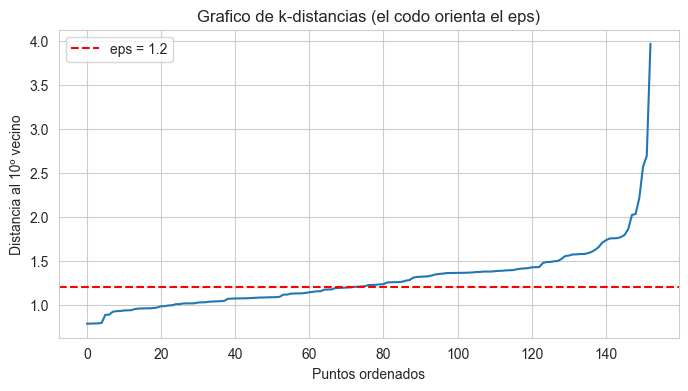

In [10]:
# Grafico de k-distancias: distancia de cada punto a su vecino nº min_samples
neigh = NearestNeighbors(n_neighbors=min_samples)
distances, _ = neigh.fit(X).kneighbors(X)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.axhline(y=1.2, color="red", linestyle="--", label="eps = 1.2")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}º vecino")
plt.title("Grafico de k-distancias (el codo orienta el eps)")
plt.legend()
plt.show()

In [11]:
eps_elegido = 1.2
dbscan = DBSCAN(eps=eps_elegido, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
print(f"DBSCAN(eps={eps_elegido}, min_samples={min_samples})")
print("Clusters encontrados:", n_clusters)
print("\nReparto de etiquetas (-1 = anomalias):")
print(pd.Series(labels_dbscan).value_counts().sort_index())

DBSCAN(eps=1.2, min_samples=10)
Clusters encontrados: 3

Reparto de etiquetas (-1 = anomalias):
-1    22
 0    51
 1    49
 2    31
Name: count, dtype: int64


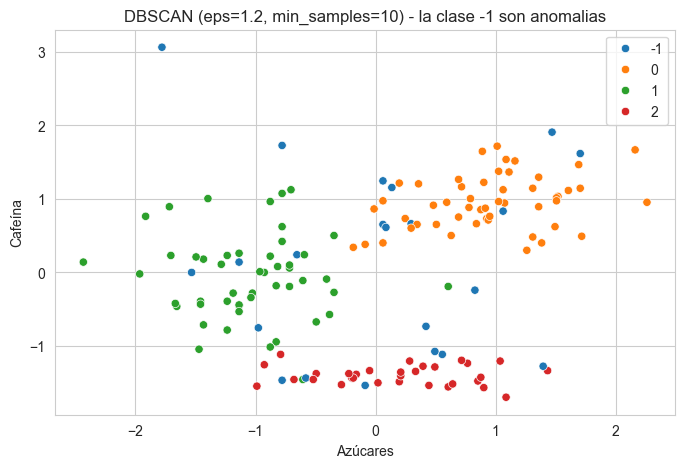

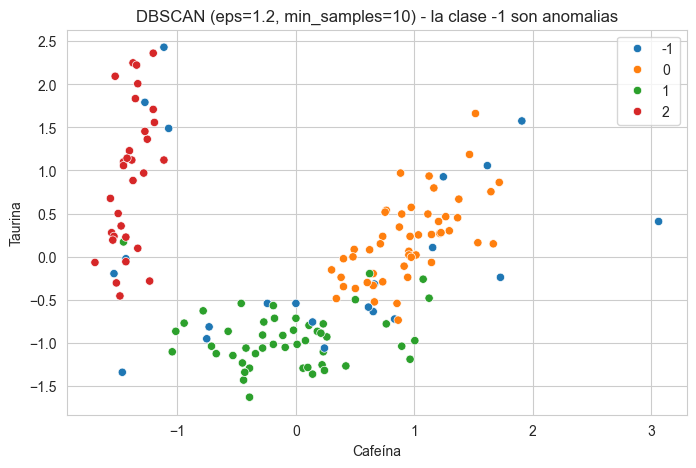

In [12]:
# Visualizamos los clusters de DBSCAN sobre la pareja Azucares vs Cafeina
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 2], hue=labels_dbscan, palette="tab10", legend="full")
plt.xlabel(COL_X); plt.ylabel(COL_Y)
plt.title(f"DBSCAN (eps={eps_elegido}, min_samples={min_samples}) - la clase -1 son anomalias")
plt.show()

#Igual, pareja Cafeina vs Taurina
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 2], y=X[:, 4], hue=labels_dbscan, palette="tab10", legend="full")
plt.xlabel(COL_X2); plt.ylabel(COL_Y2)
plt.title(f"DBSCAN (eps={eps_elegido}, min_samples={min_samples}) - la clase -1 son anomalias")
plt.show()

DBSCAN encuentra **3 segmentos** y marca ~14% como **anomalías** (-1): puntos en zonas de baja densidad o "entre" grupos.

#### 4 y 5. Modelo B - Clustering Jerárquico (aglomerativo)

Lo elegimos porque el enunciado pide **relacionar los segmentos** (cuáles se parecen más entre sí), y eso lo da el **dendrograma**. Lo pintamos (*ward*, *euclidiana*) y elegimos k con el **mayor salto (gap)**.

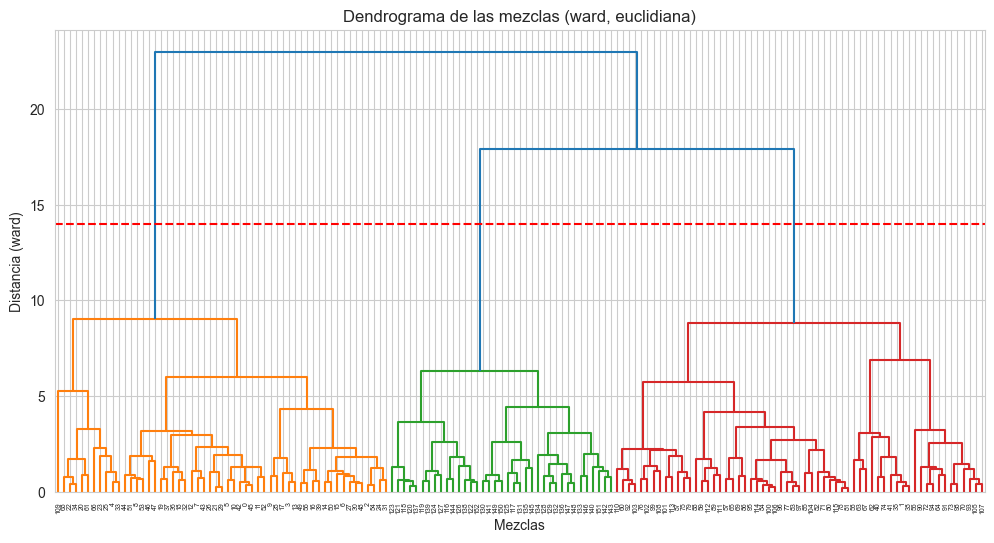

In [13]:
plt.figure(figsize=(12, 6))
plt.title("Dendrograma de las mezclas (ward, euclidiana)")
linkage_matrix = shc.linkage(X, method="ward", metric="euclidean")
shc.dendrogram(Z=linkage_matrix)
plt.axhline(y=14, color="red", linestyle="--")   # corte dentro del mayor hueco
plt.xlabel("Mezclas")
plt.ylabel("Distancia (ward)")
plt.show()

La línea roja cruza el mayor hueco **3 veces** → **3 clusters**, coherente con DBSCAN y la nota de los químicos.

**Relación entre segmentos:** dos grupos se fusionan a baja altura (más parecidos) y el tercero se une después → **dos segmentos similares y uno más diferenciado**.

In [14]:
hier = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
labels_hier = hier.fit_predict(X)
print("Clustering jerarquico con 3 clusters")
print("\nReparto de etiquetas:")
print(pd.Series(labels_hier).value_counts().sort_index())

Clustering jerarquico con 3 clusters

Reparto de etiquetas:
0    55
1    61
2    37
Name: count, dtype: int64


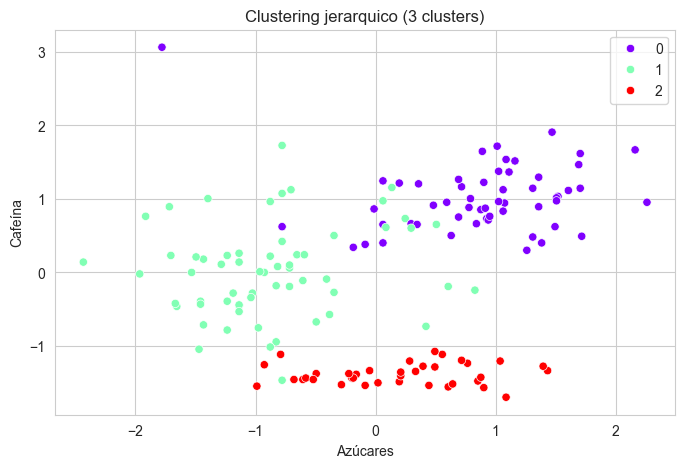

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 2], hue=labels_hier, palette="rainbow", legend="full")
plt.xlabel(COL_X); plt.ylabel(COL_Y)
plt.title("Clustering jerarquico (3 clusters)")
plt.show()

#### 6 y 7. Comparación de los dos modelos (especulativa)

Comparamos con el **coeficiente de silueta** (compacidad/separación; -1 a 1, más alto mejor). En DBSCAN lo calculamos **sin anomalías**.

In [16]:
sil_hier = silhouette_score(X, labels_hier)

mask = labels_dbscan != -1                     # DBSCAN sin anomalias
sil_dbscan = silhouette_score(X[mask], labels_dbscan[mask])

print(f"Silueta clustering jerarquico (k=3): {sil_hier:.3f}")
print(f"Silueta DBSCAN (sin anomalias):      {sil_dbscan:.3f}")

print("\nNº de mezclas por segmento:")
comp = pd.DataFrame({"DBSCAN": pd.Series(labels_dbscan).value_counts().sort_index(),
                     "Jerarquico": pd.Series(labels_hier).value_counts().sort_index()})
print(comp)

Silueta clustering jerarquico (k=3): 0.384
Silueta DBSCAN (sin anomalias):      0.453

Nº de mezclas por segmento:
    DBSCAN  Jerarquico
-1      22         NaN
 0      51        55.0
 1      49        61.0
 2      31        37.0


**Discusión:**
- Ambos coinciden en **3 segmentos** (3-5 esperados).
- La silueta de DBSCAN (~0.45) supera a la del jerárquico (~0.38), pero es **tramposa**: la logra dejando fuera el ~14% más difícil (anomalías); el jerárquico etiqueta todo.
- El jerárquico da clusters más equilibrados e **interpretables** (el dendrograma da la relación entre segmentos). DBSCAN solo halla los 3 grupos en una ventana muy estrecha de `eps` (densidades parecidas, su punto débil).
- Nos quedamos con el **jerárquico** como referencia.

**¿Por qué es especulativa?** No supervisado = **sin target** para validar. Solo tenemos métricas internas (silueta) y que el nº de grupos cuadre. La validación real llega si los químicos interpretan los segmentos (o aparece una etiqueta real, como en la Parte III).

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

Ni DBSCAN ni el jerárquico tienen `.predict()`. Como en el workout, **entrenamos un KNN** con las etiquetas de cluster y clasificamos los nuevos experimentos.

Usamos las etiquetas del **jerárquico**: es el modelo más limpio (sin anomalías) y fiable de la Parte I.

In [17]:
new_exp = pd.read_csv("./data/new_experiments.csv", sep="|")
print("Nuevos experimentos:", new_exp.shape)
new_exp

Nuevos experimentos: (6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


In [18]:
# Entrenamos un KNN con las mezclas originales y sus etiquetas de cluster (jerarquico)
knn = KNeighborsClassifier(n_neighbors=min_samples)   # mismo orden de magnitud que min_samples
knn.fit(X, labels_hier)

# Clasificamos los nuevos experimentos
nuevos_labels = knn.predict(new_exp.values)
print("Segmento asignado a cada nuevo experimento:")
print(nuevos_labels)

Segmento asignado a cada nuevo experimento:
[0 0 1 1 2 2]


In [19]:
resultado_nuevos = new_exp.copy()
resultado_nuevos["segmento"] = nuevos_labels
resultado_nuevos

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,segmento
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,1
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,1
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


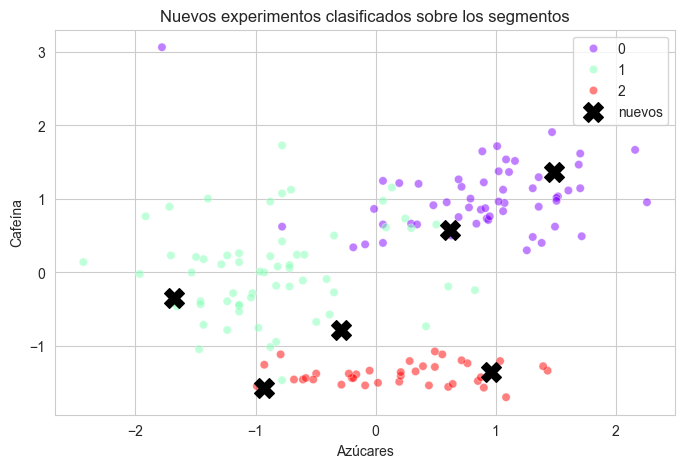

In [20]:
# Nuevos experimentos (X negras) sobre los segmentos existentes
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 2], hue=labels_hier, palette="rainbow", alpha=0.5, legend="full")
plt.scatter(new_exp.values[:, 0], new_exp.values[:, 2],
            c="black", marker="X", s=200, label="nuevos")
plt.xlabel(COL_X); plt.ylabel(COL_Y)
plt.title("Nuevos experimentos clasificados sobre los segmentos")
plt.legend()
plt.show()

El KNN asigna los 6 experimentos a un segmento y caen en zonas coherentes con su color. (En la Parte III veremos si coinciden con la energización real.)

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

Ya hay **etiqueta real** de energización (1=media, 2=media-alta, 3=alta) en `power_results.csv`: las **153 primeras** filas son las mezclas originales y las **6 últimas** los nuevos experimentos.

Como los clusters llevan etiquetas arbitrarias (0,1,2), comparamos con:
- **Crosstab**: si cada cluster cae en una sola clase real.
- **ARI**: acuerdo entre agrupaciones ignorando los nombres (1 = idénticas, ~0 = azar).

In [21]:
power = pd.read_csv("./data/power_results.csv")
clase_real = power["class"].values

clase_orig = clase_real[:153]     # mezclas originales
clase_nuevos = clase_real[153:]   # nuevos experimentos (6)

print("Reparto de la clase real (mezclas originales):")
print(pd.Series(clase_orig).value_counts().sort_index())

Reparto de la clase real (mezclas originales):
1    56
2    60
3    37
Name: count, dtype: int64


In [22]:
print("Clustering jerarquico vs energizacion real:")
pd.crosstab(pd.Series(labels_hier, name="cluster_jerarquico"),
            pd.Series(clase_orig, name="clase_real"))

Clustering jerarquico vs energizacion real:


clase_real,1,2,3
cluster_jerarquico,,,
0,51,4,0
1,5,56,0
2,0,0,37


In [23]:
print("DBSCAN vs energizacion real (-1 = anomalias):")
pd.crosstab(pd.Series(labels_dbscan, name="cluster_DBSCAN"),
            pd.Series(clase_orig, name="clase_real"))

DBSCAN vs energizacion real (-1 = anomalias):


clase_real,1,2,3
cluster_DBSCAN,,,
-1,6,11,5
0,50,1,0
1,0,48,1
2,0,0,31


In [24]:
ari_hier = adjusted_rand_score(clase_orig, labels_hier)
ari_dbscan = adjusted_rand_score(clase_orig, labels_dbscan)
print(f"ARI jerarquico vs clase real: {ari_hier:.3f}")
print(f"ARI DBSCAN     vs clase real: {ari_dbscan:.3f}")

ARI jerarquico vs clase real: 0.816
ARI DBSCAN     vs clase real: 0.733


**Lectura:**
- Cada cluster cae mayoritariamente en **una** clase real → capturamos los 3 niveles de energización.
- **ARI jerárquico (~0.82) > DBSCAN (~0.73)**: DBSCAN pierde por las anomalías (-1), que sí tenían clase.
- Sin ver la etiqueta real, el clustering (sobre todo el jerárquico) daba una segmentación **muy parecida a la realidad**.

In [25]:
# Acerto el KNN de la Parte II con los 6 nuevos experimentos?
comparacion = pd.DataFrame({"predicho_KNN": nuevos_labels, "clase_real": clase_nuevos})
print(comparacion.to_string(index=False))
print(f"\nARI (nuevos experimentos): {adjusted_rand_score(clase_nuevos, nuevos_labels):.3f}")

 predicho_KNN  clase_real
            0           1
            0           1
            1           2
            1           2
            2           3
            2           3

ARI (nuevos experimentos): 1.000


**Conclusión final:** con solo las cantidades de componentes, el clustering recupera una segmentación fiel a la energización real (mapeo consistente: cluster 0~nivel 1, 1~nivel 2, 2~nivel 3; el KNN acierta los 6 nuevos).

El **jerárquico** fue el más sencillo, estable e interpretable, y su **dendrograma** responde a qué segmentos se parecen más entre sí.